In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [51]:
dfUSA = df[(df["job_country"] == "United States") & (df["job_title_short"] == "Data Analyst")].copy()
dfUSA["job_posted_month_num"] = dfUSA["job_posted_date"].dt.month
dfUSA["job_posted_month_name"] = dfUSA["job_posted_date"].dt.month_name()
dfUSA = dfUSA.explode("job_skills")
dfUSAPiv = dfUSA.pivot_table(index=["job_posted_month_num","job_posted_month_name"], columns="job_skills", aggfunc="size", fill_value=0)
dfUSAPiv = dfUSAPiv.droplevel("job_posted_month_num")
dfUSAPiv.loc["Total"] = dfUSAPiv.sum()
dfUSAPiv


job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month_name,,,,,,,,,,,,,,,,,,,,,
January,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
February,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
March,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
April,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
May,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
June,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
July,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
August,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
September,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


In [61]:
# dfUSAPiv.loc["Total"].sort_values(ascending=False).head(5).index.to_list()
upddf = dfUSAPiv[dfUSAPiv.loc["Total"].sort_values(ascending=False).head(5).index.to_list()]

upddf = upddf.drop("Total")
upddf


job_skills,sql,excel,tableau,python,sas
job_posted_month_name,,,,,
January,4601,3592,2488,2254,1832
February,3168,2587,1676,1618,1212
March,3226,2661,1804,1683,1238
April,3220,2549,1789,1679,1302
May,2581,2118,1432,1349,972
June,2862,2382,1628,1609,984
July,2609,2118,1533,1438,996
August,3414,2731,1951,2025,1276
September,2295,1801,1353,1229,856


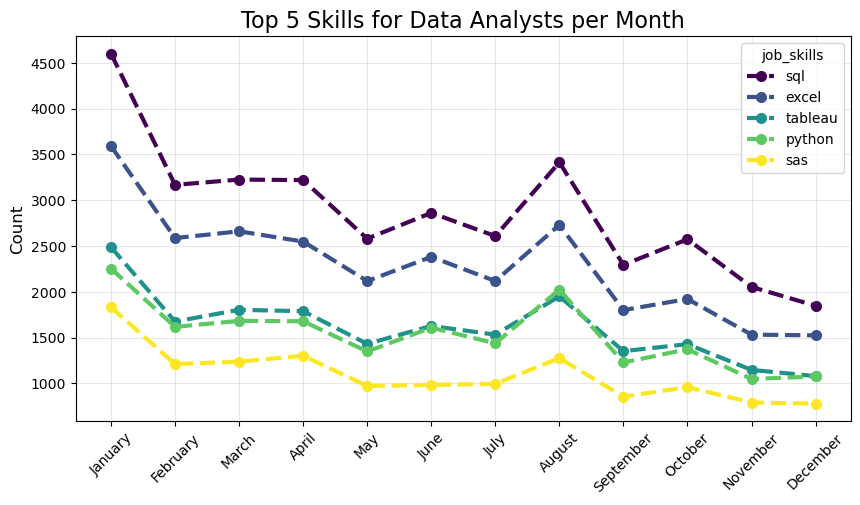

In [67]:
upddf.iloc[:, :5].plot(
    kind='line',
    linewidth=3,
    linestyle='--',
    colormap='viridis',
    marker='o',
    markersize=7,
    figsize=(10, 5)
)

plt.title('Top 5 Skills for Data Analysts per Month', fontsize=16)
plt.ylabel('Count', fontsize=12)
plt.xlabel('')

plt.xticks(
    range(len(upddf.index)),
    upddf.index,
    rotation=45
)

plt.grid(alpha=0.3)

plt.show()